# Image segmenter
An 2D image is a single or multiple arrays. Each array corresponds to Red, Green, or Blue in an image, where each cell corresponds to the color brightness at a given location. This collection of arrays, and all their pixels, comprises the image in totality. The purpose of this script is to randomly or regementally split an image array into small chunks that can be can be used in subsequent applications.

### Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from skimage import io

## First let's import a cool test image

In [3]:
test_image = io.imread('/home/unitx/wabbit_playground/nn/minecraft/archering_2375.png')

## Let's look at it...

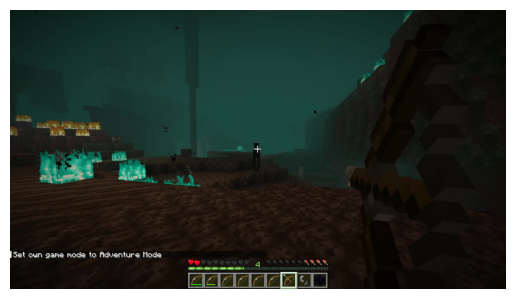

In [4]:
plt.imshow(test_image)
plt.axis('off')
plt.show()

## Looks cool... now let's split it up by color channel

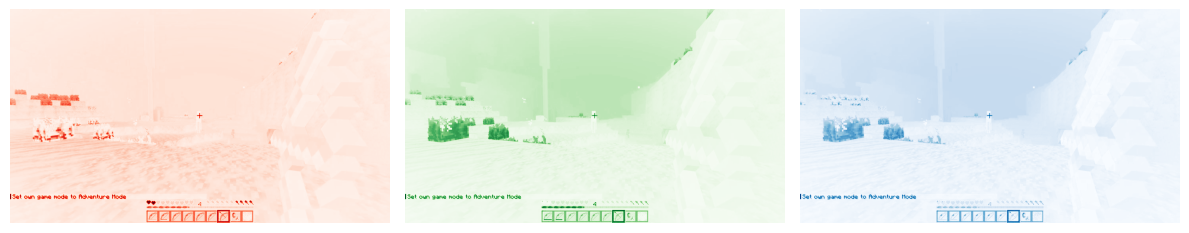

In [5]:
test_reds = np.array(test_image[:, :, 0]) / 255
test_greens = np.array(test_image[:, :, 1]) / 255
test_blues = np.array(test_image[:, :, 2]) / 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(test_reds, cmap='Reds')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(test_greens, cmap='Greens')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(test_blues, cmap='Blues')
plt.axis('off')
plt.tight_layout()
plt.show()

## Woahhhh okay so now that we have arrays, let's see how we can fragment them

### Fragmenter 1: Nice and Tidy
The following fragmenter takes an array and split's it up nicely. Given the desired fragment size *n*, we will split the image into *nxn* fragments starting from index (0,0) to index (X-1,Y-1) where X is the pixel width of the image and Y is the pixel height.

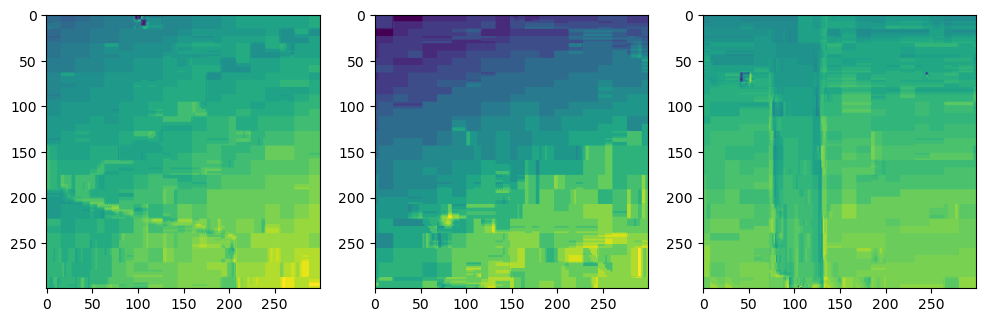

In [28]:
def fragmenter_one(image, fragment_size):
    height, width = image.shape
    fragments = []
    num_yits = height // fragment_size
    num_xits = width // fragment_size
    for j in range(num_yits):
        for i in range(num_xits):
            y = j*fragment_size
            x = i*fragment_size
            fragment = image[y:y+fragment_size, x:x+fragment_size]
            fragments.append(fragment)
    return fragments

# print(test_reds.shape)
frags  = fragmenter_one(test_reds, 300)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(frags[0])
plt.subplot(1, 3, 2)
plt.imshow(frags[1])
plt.subplot(1, 3, 3)
plt.imshow(frags[2])
plt.show()

### Fragmenter 2: Random Breaks